In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [2]:
with open('data_simple_line_perturbed_2D_1000_turns.pkl', 'rb') as f:
    data = pickle.load(f)

In [3]:
data.keys()

dict_keys(['x', 'px'])

In [4]:
data['x'].shape, data['px'].shape

((1600, 1001), (1600, 1001))

Text(0, 0.5, '$p_x$')

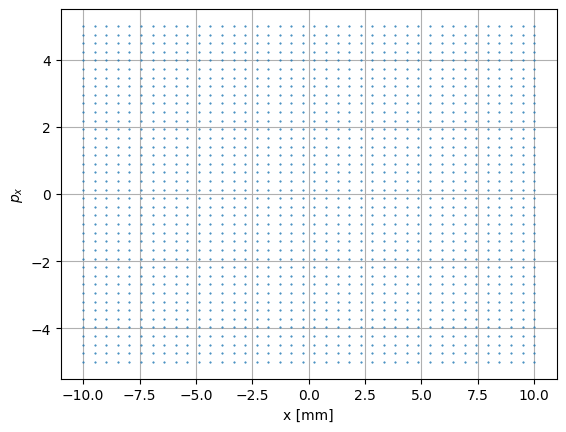

In [5]:
plt.plot(data['x'][:, 0] * 1000, data['px'][:, 0] * 1000, '.', markersize=1, color='C0')
plt.grid()
plt.xlabel('x [mm]')
plt.ylabel(r'$p_x$')

In [6]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from models import GSympNet

In [7]:
# Hyperparameters
dim = 2
layers = 3
width = 20
activation = torch.sigmoid
epochs = 100
batch_size = 64
learning_rate = 1e-3

In [8]:
# x_xp_data_list = [np.array([data['x'][i, :], data['px'][i, :]]).T for i in range(data['x'].shape[0])]
x_xp_data_list = [np.array([data['x'][i, :], data['px'][i, :]]).T for i in range(1200)]
x_xp_data = np.vstack(x_xp_data_list)

In [9]:
x_xp_data.shape

(1201200, 2)

In [ ]:
def min_max_normalize(arr, min_val=None, max_val=None):
    """
    Min-max normalize a numpy array or torch tensor of shape (N, 2) to range [-1, 1].
    If min_val and max_val are not provided, compute from arr along axis=0.
    Returns normalized array, min_val, and max_val.
    """
    if min_val is None:
        min_val = arr.min(axis=0, keepdims=True)
    if max_val is None:
        max_val = arr.max(axis=0, keepdims=True)
    normalized = 2 * (arr - min_val) / (max_val - min_val) - 1
    return normalized, min_val, max_val

def min_max_denormalize(arr, min_val, max_val):
    """
    Denormalize a numpy array or torch tensor of shape (N, 2) from range [-1, 1]
    back to the original range defined by min_val and max_val.
    """
    return (arr + 1) / 2 * (max_val - min_val) + min_val

In [12]:
x_xp_data_norm, min, max = min_max_normalize(x_xp_data)

In [13]:
x_xp_data_norm

array([[-0.80891385, -0.51177931],
       [ 0.07020423,  0.98192424],
       [ 0.68518646, -0.78099891],
       ...,
       [-0.87064917,  0.09372846],
       [ 0.57188541,  0.588096  ],
       [ 0.09832285, -0.86932379]], shape=(1201200, 2))

In [14]:
input, output = x_xp_data_norm[:-1], x_xp_data_norm[1:]

In [15]:
input-output

array([[-0.87911808, -1.49370355],
       [-0.61498224,  1.76292315],
       [ 1.68373775, -0.83112678],
       ...,
       [ 1.42948993, -0.80340744],
       [-1.44253457, -0.49436754],
       [ 0.47356256,  1.4574198 ]], shape=(1201199, 2))

In [16]:
train_x = torch.tensor(input, dtype=torch.float32)
train_y = torch.tensor(output, dtype=torch.float32)

In [17]:
train_x.shape

torch.Size([1201199, 2])

In [18]:
dataset = TensorDataset(train_x, train_y)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [19]:
model = GSympNet(dim, layers, width, activation)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = torch.nn.MSELoss()

In [20]:
model.train()
for epoch in range(epochs):
    total_loss = 0.0
    for x_batch, y_batch in loader:
        optimizer.zero_grad()
        pred = model(x_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x_batch.size(0)
    avg_loss = total_loss / len(dataset)    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.10f}")

Epoch 1/100, Loss: 0.0587015810
Epoch 2/100, Loss: 0.0007095148
Epoch 3/100, Loss: 0.0005939834
Epoch 4/100, Loss: 0.0005643383
Epoch 5/100, Loss: 0.0005435648
Epoch 6/100, Loss: 0.0005296172
Epoch 7/100, Loss: 0.0005210337
Epoch 8/100, Loss: 0.0005153576
Epoch 9/100, Loss: 0.0005114159
Epoch 10/100, Loss: 0.0005080720
Epoch 11/100, Loss: 0.0005051538
Epoch 12/100, Loss: 0.0005035232
Epoch 13/100, Loss: 0.0005016764
Epoch 14/100, Loss: 0.0004997842
Epoch 15/100, Loss: 0.0004981178
Epoch 16/100, Loss: 0.0004963482
Epoch 17/100, Loss: 0.0004952574
Epoch 18/100, Loss: 0.0004952785
Epoch 19/100, Loss: 0.0004932464
Epoch 20/100, Loss: 0.0004925636
Epoch 21/100, Loss: 0.0004911698
Epoch 22/100, Loss: 0.0004905817
Epoch 23/100, Loss: 0.0004890128
Epoch 24/100, Loss: 0.0004883909
Epoch 25/100, Loss: 0.0004873242
Epoch 26/100, Loss: 0.0004870351
Epoch 27/100, Loss: 0.0004859248
Epoch 28/100, Loss: 0.0004851503
Epoch 29/100, Loss: 0.0004844832
Epoch 30/100, Loss: 0.0004841906
Epoch 31/100, Loss:

In [21]:
x_xp_test_list = [np.array([data['x'][i, :], data['px'][i, :]]).T for i in range(1200, 1600)]
x_xp_test = np.vstack(x_xp_test_list)

In [22]:
x_xp_test.shape

(400400, 2)

In [23]:
x_xp_test_tensor = torch.tensor(x_xp_test, dtype=torch.float32)

In [24]:
x_xp_test_tensor.shape

torch.Size([400400, 2])

In [25]:
pred = model.predict(x_xp_test_tensor)

In [26]:
pred.shape

torch.Size([400400, 1, 2])

In [29]:
pred_reshaped = pred.squeeze().reshape(400, 1001, 2)
true_reshaped = x_xp_test_tensor.reshape(400, 1001, 2)

Text(0, 0.5, '$p_x$')

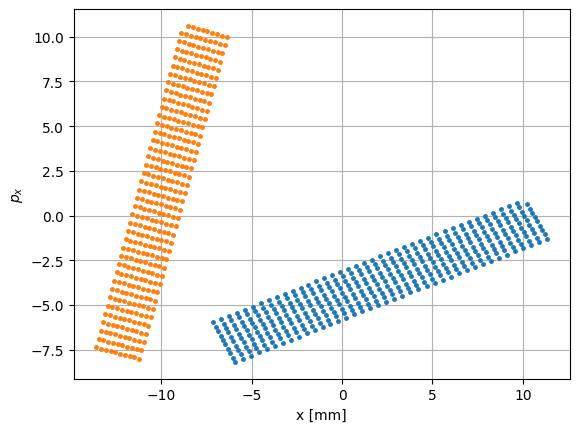

In [30]:
time_step = 100
plt.plot(true_reshaped[1:, time_step, 0].detach().numpy() * 1000, true_reshaped[1:, time_step, 1].detach().numpy() * 1000, '.', markersize=5, color='C0')
plt.plot(pred_reshaped[:-1, time_step, 0].detach().numpy() * 1000, pred_reshaped[:-1, time_step, 1].detach().numpy() * 1000, '.', markersize=5, color='C1')
plt.grid()
plt.xlabel('x [mm]')
plt.ylabel(r'$p_x$')

In [ ]:
# initial position, momentum particles 700 to 1600
x_xp_init_test_list = [np.array([data['x'][i, 0], data['px'][i, 0]]).T for i in range(700, 1600)]
x_xp_init_test = np.vstack(x_xp_init_test_list)

In [ ]:
x_xp_init_test_norm, min, max = min_max_normalize(x_xp_init_test)

In [37]:
x_xp_init_test.shape

(900, 2)

In [38]:
x_xp_init_test_tensor = torch.tensor(x_xp_init_test, dtype=torch.float32)

In [39]:
pred_init = model.predict(x_xp_init_test_tensor, steps=1001)

In [40]:
pred_init.shape

torch.Size([900, 1001, 2])

Text(0, 0.5, '$p_x$')

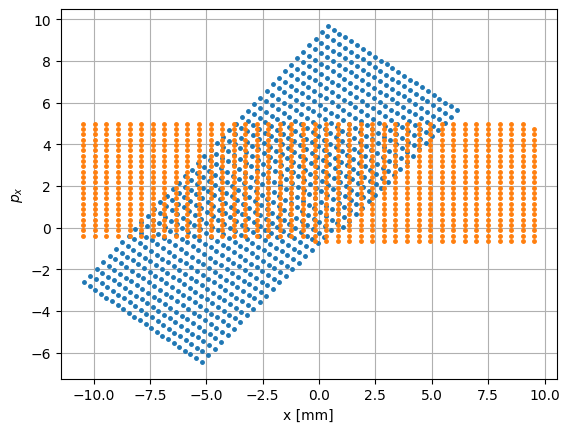

In [49]:
time_step = 200
plt.plot(true_reshaped[1:, time_step, 0].detach().numpy() * 1000, true_reshaped[1:, time_step, 1].detach().numpy() * 1000, '.', markersize=5, color='C0')
plt.plot(pred_init[:-1, time_step, 0].detach().numpy() * 1000, pred_init[:-1, time_step, 1].detach().numpy() * 1000, '.', markersize=5, color='C1')
plt.grid()
plt.xlabel('x [mm]')
plt.ylabel(r'$p_x$')